In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Exploración de características físicas de los open clusters

## Importar tablas

In [2]:
clusters = pd.read_csv('../data/processed/open_clusters.csv')
members = pd.read_csv('../data/processed/members.csv')

Se selecciona un cúmulo aleatorio.

In [113]:
cluster_num = np.random.randint(0, len(clusters))

In [114]:
cluster = clusters.iloc[cluster_num, :]
cluster_name = cluster['Name']
cluster_members = members[members['Name'] == cluster_name].copy()

Se extraen la ascensión recta y declinación del punto más denso del cúmulo.

In [115]:
ra0 = cluster['RA_ICRS']
dec0 = cluster['DE_ICRS']

Se extraen las coordenadas de los miembros del cúmulo.

In [116]:
ras = cluster_members['RA_ICRS'].values
decs = cluster_members['DE_ICRS'].values

## Cálculo de la densidad de área del cúmulo

Se calculan las distancias angulares de los miembros del cúmulo al punto más denso de este.

In [117]:
def angular_distances(ra0, dec0, ras, decs):
    ra0 = np.radians(ra0)
    dec0 = np.radians(dec0)
    ras = np.radians(ras)
    decs = np.radians(decs)

    delta_ra = ras - ra0
    delta_dec = decs - dec0

    a = np.sin(delta_dec / 2)**2 + np.cos(dec0) * np.cos(decs) * np.sin(delta_ra / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return c

In [118]:
rs = angular_distances(ra0, dec0, ras, decs)

Se definen los límites de los anillos.

In [154]:
r_max = np.max(rs)
num_bins = 19
bins = np.linspace(0, r_max, num_bins + 1)

Se cuenta el número de estrellas en cada anillo.

In [155]:
counts, edges = np.histogram(rs, bins=bins)

Se calcula el área de cada anillo de la forma: $$A = \pi \left(r_\text{int}^2 - r_\text{ext}^2\right)$$ donde $r_\text{int}$ es el radio interior y $r_\text{ext}$ es el radio exterior de cada bin.

In [156]:
areas = np.pi * (edges[1:]**2 - edges[:-1]**2)

Se calculan las densidades de número.

In [157]:
densities = counts / areas

Se calculan los radios medios de cada bin.

In [158]:
r_mid = (edges[:-1] + edges[1:]) / 2

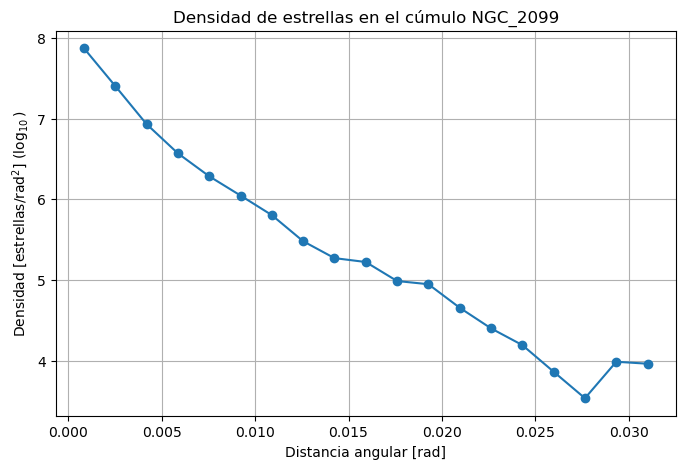

In [159]:
plt.figure(figsize=(8, 5))
plt.plot(r_mid, np.log10(densities), marker='o')
plt.xlabel('Distancia angular [rad]')
plt.ylabel('Densidad [estrellas/rad$^2$] ($\log_{10}$)')
plt.title(f'Densidad de estrellas en el cúmulo {cluster_name}')
plt.grid()
plt.show()

## Cálculo de los valores medios de movimiento propio (RA/DEC), índice de color, velocidad radial por anillo

Se añaden las distancias angulares a la tabla de los miembros del cúmulo.

In [160]:
cluster_members['ang_dist'] = rs

Se crea una nueva columna que asigne cada estrella a su anillo correspondiente.

In [161]:
cluster_members['ring'] = pd.cut(cluster_members['ang_dist'], bins=bins, 
                                 include_lowest=True)

Se agrupa por anillo y se calcula la media.

In [166]:
columns = ['pmRA', 'pmDE', 'BP-RP', 'RV']
mean_values = cluster_members.groupby('ring', observed=False)[columns].mean()

### Movimiento propio medio en RA por anillo

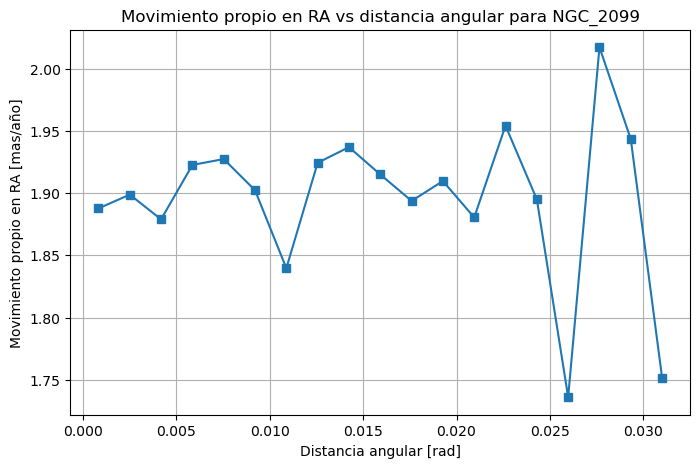

In [172]:
plt.figure(figsize=(8, 5))
plt.plot(r_mid, mean_values['pmRA'], marker='s')
plt.xlabel('Distancia angular [rad]')
plt.ylabel('Movimiento propio en RA [mas/año]')
plt.title(f'Movimiento propio en RA vs distancia angular para {cluster_name}')
plt.grid()
plt.show()

### Movimiento propio en DEC por anillo

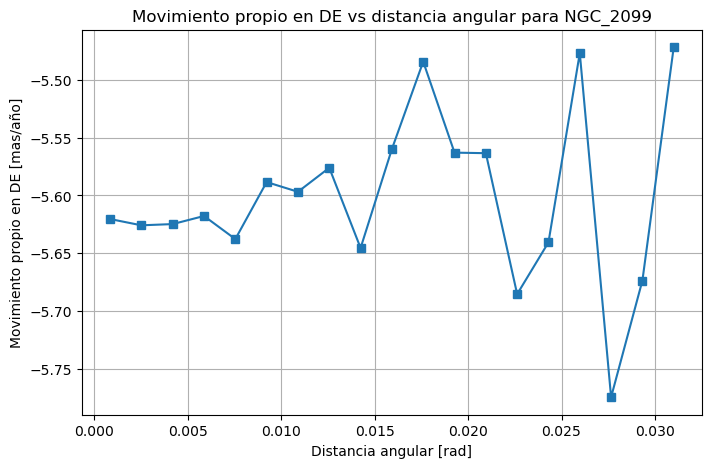

In [173]:
plt.figure(figsize=(8, 5))
plt.plot(r_mid, mean_values['pmDE'], marker='s')
plt.xlabel('Distancia angular [rad]')
plt.ylabel('Movimiento propio en DE [mas/año]')
plt.title(f'Movimiento propio en DE vs distancia angular para {cluster_name}')
plt.grid()
plt.show()

### Índice de color medio por anillo

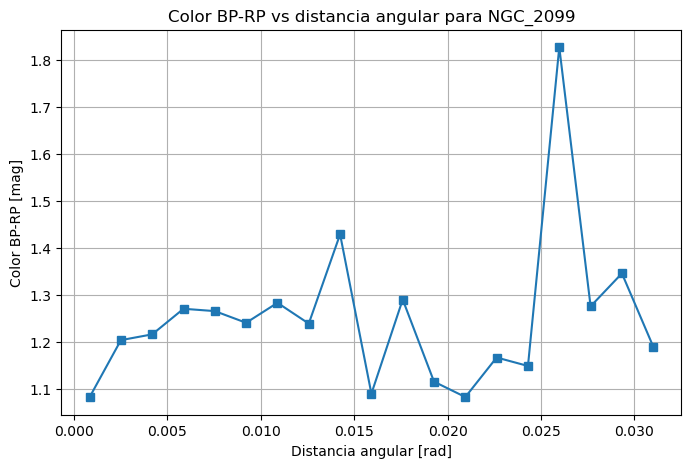

In [174]:
plt.figure(figsize=(8, 5))
plt.plot(r_mid, mean_values['BP-RP'], marker='s')
plt.xlabel('Distancia angular [rad]')
plt.ylabel('Color BP-RP [mag]')
plt.title(f'Color BP-RP vs distancia angular para {cluster_name}')
plt.grid()
plt.show()

### Velocidad radial media por anillo

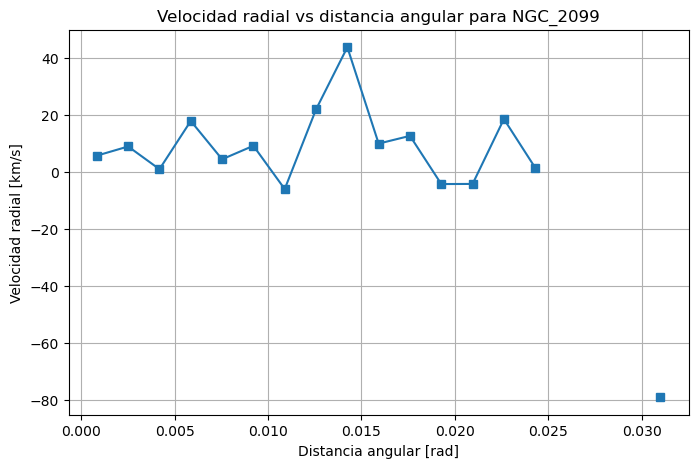

In [175]:
plt.figure(figsize=(8, 5))
plt.plot(r_mid, mean_values['RV'], marker='s')
plt.xlabel('Distancia angular [rad]')
plt.ylabel('Velocidad radial [km/s]')
plt.title(f'Velocidad radial vs distancia angular para {cluster_name}')
plt.grid()
plt.show()